In [7]:
import sklearn
import sklearn.datasets
import numpy as np
import matplotlib.pyplot as plt


def load_extra_datasets(N=200):
    noisy_circles = sklearn.datasets.make_circles(n_samples=N, factor=0.5, noise=0.3)
    noisy_moons = sklearn.datasets.make_moons(n_samples=N, noise=0.2)
    blobs = sklearn.datasets.make_blobs(
        n_samples=N, random_state=5, n_features=2, centers=6
    )
    gaussian_quantiles = sklearn.datasets.make_gaussian_quantiles(
        mean=None,
        cov=0.5,
        n_samples=N,
        n_features=2,
        n_classes=2,
        shuffle=True,
        random_state=None,
    )
    no_structure = np.random.rand(N, 2), np.random.rand(N, 2)

    return noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure

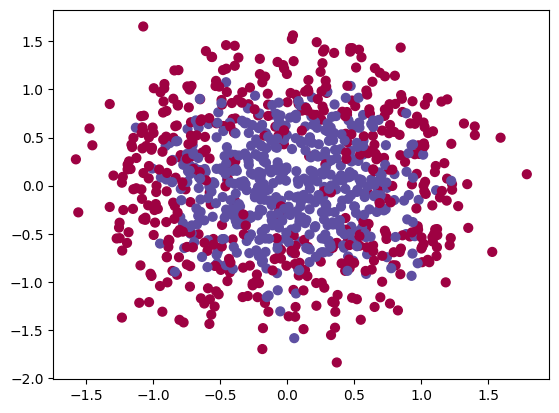

In [12]:
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = (
    load_extra_datasets(1000)
)

datasets = {
    "noisy_circles": noisy_circles,
    "noisy_moons": noisy_moons,
    "blobs": blobs,
    "gaussian_quantiles": gaussian_quantiles,
}

### START CODE HERE ### (choose your dataset)
dataset = "noisy_circles"
### END CODE HERE ###

X, Y = datasets[dataset]
X, Y = X.T, Y.reshape(1, Y.shape[0])

# make blobs binary
if dataset == "blobs":
    Y = Y % 2

# Visualize the data
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral)

In [18]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

In [20]:
W11 = np.array([2, 4])
W12 = np.array([1, 3])
W13 = np.array([-1, 2])
b1 = 0
W21 = np.array([-1, 2, 4])
W22 = np.array([2, -3, 2])
b2 = 0
W31 = np.array([2, -1])
b3 = 0
X1 = np.array([1, 1])

In [21]:
Z11 = W11 @ X1 + b1
Z12 = W12 @ X1 + b1
Z13 = W13 @ X1 + b1
Z1 = np.array([Z11, Z12, Z13])
print(f"Z1 = {Z1}")
A1 = np.where(Z1 > 0, Z1, 0)
print(f"A1 = {A1}")

Z1 = [6 4 1]
A1 = [6 4 1]


In [22]:
Z21 = W21 @ A1 + b2
Z22 = W22 @ A1 + b2
Z2 = np.array([Z21, Z22])
print(f"Z2 = {Z2}")
A2 = np.where(Z2 > 0, Z2, 0)
print(f"A2 = {A2}")

Z2 = [6 2]
A2 = [6 2]


In [23]:
Z3 = W31 @ A2 + b3
print(f"Z3 = {Z3}")
A3 = sigmoid(Z3)
print(f"A3 = {A3}")

Z3 = 10
A3 = 0.9999546021312976


In [24]:
Loss = -(1 * np.log(A3))
print(Loss)

4.539889921682063e-05


In [ ]:
dA3 = -(1 / A3)
print(dA3)

-1.0000453999297625


In [26]:
dZ3 = Z3 * (1 - Z3)
print(dZ3)

-90


In [ ]:
dW3 = dZ3 * A2

ValueError: matmul: Input operand 0 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [33]:
import numpy as np

# Number of weights
n_in, n_out = 1, 1_000

# Different scales
scales = [0.001, 0.01, 0.1, 1]

for scale in scales:
    W = np.random.randn(n_out, n_in) * scale
    print(f"Scale: {scale}")
    print(f"Mean of W: {W.mean():.5f}")
    print(f"Std of W: {W.std():.5f}")
    print(f"Min / Max: {W.min():.5f} / {W.max():.5f}")
    print(f"Approx ±1σ: [{W.mean() - W.std():.5f}, {W.mean() + W.std():.5f}]")
    print("-" * 40)

Scale: 0.001
Mean of W: -0.00003
Std of W: 0.00103
Min / Max: -0.00350 / 0.00319
Approx ±1σ: [-0.00105, 0.00100]
----------------------------------------
Scale: 0.01
Mean of W: 0.00000
Std of W: 0.01025
Min / Max: -0.04186 / 0.02894
Approx ±1σ: [-0.01025, 0.01025]
----------------------------------------
Scale: 0.1
Mean of W: 0.00360
Std of W: 0.09904
Min / Max: -0.31859 / 0.32080
Approx ±1σ: [-0.09544, 0.10264]
----------------------------------------
Scale: 1
Mean of W: -0.01242
Std of W: 1.01458
Min / Max: -4.01099 / 3.34160
Approx ±1σ: [-1.02700, 1.00217]
----------------------------------------
